# 01 — Data Understanding

The purpose of this notebook is to understand the raw Excel workbook before cleaning, visualizing, or modelling the data.

In this first section, we only import the required tools, locate the dataset, and inspect its worksheet names.

In [4]:
from pathlib import Path

import pandas as pd

# The notebook is inside the notebooks folder, so its parent folder is the project root.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_file = project_root / "feeder_2023_2025.xlsx"

# Confirm that Python can find the dataset before trying to read it.
if not data_file.exists():
    raise FileNotFoundError(f"Dataset not found: {data_file}")

excel_file = pd.ExcelFile(data_file)

print(f"Dataset: {data_file.name}")
print(f"Worksheets: {excel_file.sheet_names}")

Dataset: feeder_2023_2025.xlsx
Worksheets: ['Hourly_Data', 'Metadata']


## Inspect the metadata sheet

Metadata is information that describes the dataset. Reading it first helps us interpret the hourly measurements correctly and avoids making unsupported assumptions.

In [5]:
metadata = pd.read_excel(excel_file, sheet_name="Metadata")
metadata

,Item,Value
0,Source PDF feeder,UNIVERSITY ROAD / 11KV PARAS
1,Source PDF Sub-station Code No,1633
2,Source PDF Meter Sr No,LT005177
3,Source PDF Class of Voltage,11KV
4,Source PDF Code no of Feeder,05505216331LO2206
5,Second feeder,11KV LAXMINAGAR (synthetic)
6,Second feeder identifiers,Synthetic placeholders because they were not p...
7,Time span,2023-01-01 to 2025-12-31
8,Interval,1 hour
9,Rows per feeder,"26,304"


## Load the hourly feeder data

We now load the main worksheet into a pandas DataFrame named `df`. A DataFrame is a table with rows and columns. Displaying the first five rows lets us inspect the structure without printing the entire dataset.

In [6]:
df = pd.read_excel(excel_file, sheet_name="Hourly_Data")

df.head()

,Date,Hour Interval,Name of Sub-station,Sub-station Code No,Feeder Name,Meter Sr No,Class of Voltage,Code no of Feeder,feeder category,feeder type,...,Frequency (Hz),Power Factor,Q1,Diff in MVArh Q1,Q2,Diff in MVArh Q2,Q3,Diff in MVArh Q3,Q4,Diff in MVArh Q4
0,2023-01-01,00:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.000421,0.980554,0.205021,0.005021,0.082869,0.002869,2.812910,0.012910,1.056455,0.006455
1,2023-01-01,01:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.016537,0.977000,0.210207,0.005186,0.085832,0.002963,2.826246,0.013336,1.063123,0.006668
2,2023-01-01,02:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.016717,0.985331,0.213910,0.003703,0.087948,0.002116,2.835768,0.009522,1.067884,0.004761
3,2023-01-01,03:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,49.994828,0.978327,0.218198,0.004289,0.090399,0.002451,2.846796,0.011028,1.073398,0.005514
4,2023-01-01,04:00,UNIVERSITY ROAD,1633,11KV PARAS,LT005177,11KV,05505216331LO2206,URBN,HT,...,50.024650,0.985041,0.221605,0.003406,0.092345,0.001946,2.855555,0.008759,1.077777,0.004379


## Check the dataset dimensions

The `shape` attribute returns two numbers: `(number of rows, number of columns)`. Rows are hourly feeder observations, while columns are the recorded fields or variables.

In [7]:
rows, columns = df.shape

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 52,608
Number of columns: 34


## List the column names

Column names tell us what information is available in the dataset. We print them one per line with a number so that the full list is easy to inspect.

In [8]:
for number, column_name in enumerate(df.columns, start=1):
    print(f"{number:>2}. {column_name}")

 1. Date
 2. Hour Interval
 3. Name of Sub-station
 4. Sub-station Code No
 5. Feeder Name
 6. Meter Sr No
 7. Class of Voltage
 8. Code no of Feeder
 9. feeder category
10. feeder type
11. feeder meter_no
12. Energy Import
13. Diff MWh Import
14. Energy Export
15. Diff MWh Export
16. MW(I)
17. MW(E)
18. MVA
19. Current Ir (Amp)
20. Current Iy (Amp)
21. Current Ib (Amp)
22. Voltage Vry (kV)
23. Voltage Vyb (kV)
24. Voltage Vbr (kV)
25. Frequency (Hz)
26. Power Factor
27. Q1
28. Diff in MVArh Q1
29. Q2
30. Diff in MVArh Q2
31. Q3
32. Diff in MVArh Q3
33. Q4
34. Diff in MVArh Q4


## Inspect column data types and completeness

The `info()` method summarizes every column. `Non-Null Count` shows how many rows contain a value, and `Dtype` shows how pandas interpreted the values. This is an initial completeness check; we will perform a detailed missing-value calculation later.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 52608 non-null  datetime64[us]
 1   Hour Interval        52608 non-null  str           
 2   Name of Sub-station  52608 non-null  str           
 3   Sub-station Code No  52608 non-null  str           
 4   Feeder Name          52608 non-null  str           
 5   Meter Sr No          52608 non-null  str           
 6   Class of Voltage     52608 non-null  str           
 7   Code no of Feeder    52608 non-null  str           
 8   feeder category      52608 non-null  str           
 9   feeder type          52608 non-null  str           
 10  feeder meter_no      52608 non-null  str           
 11  Energy Import        52608 non-null  float64       
 12  Diff MWh Import      52608 non-null  float64       
 13  Energy Export        52608 non-null  int64

## Count missing values

A missing value is an empty or unavailable entry. We count missing values column by column before deciding whether any imputation is necessary.

In [10]:
missing_values = df.isna().sum()
missing_values

Date                   0
Hour Interval          0
Name of Sub-station    0
Sub-station Code No    0
Feeder Name            0
Meter Sr No            0
Class of Voltage       0
Code no of Feeder      0
feeder category        0
feeder type            0
feeder meter_no        0
Energy Import          0
Diff MWh Import        0
Energy Export          0
Diff MWh Export        0
MW(I)                  0
MW(E)                  0
MVA                    0
Current Ir (Amp)       0
Current Iy (Amp)       0
Current Ib (Amp)       0
Voltage Vry (kV)       0
Voltage Vyb (kV)       0
Voltage Vbr (kV)       0
Frequency (Hz)         0
Power Factor           0
Q1                     0
Diff in MVArh Q1       0
Q2                     0
Diff in MVArh Q2       0
Q3                     0
Diff in MVArh Q3       0
Q4                     0
Diff in MVArh Q4       0
dtype: int64

## Check for exact duplicate rows

An exact duplicate occurs when all values in one row are identical to all values in another row. We count such rows before making any decision about removal.

In [11]:
exact_duplicate_count = df.duplicated().sum()

print(f"Number of exact duplicate rows: {exact_duplicate_count}")

Number of exact duplicate rows: 0


## Create a complete timestamp

The date and hour are stored separately. Forecasting requires a single chronological field, so we combine `Date` and `Hour Interval` into a new `timestamp` column. The original columns are retained.

In [12]:
date_text = df["Date"].dt.strftime("%Y-%m-%d")
time_text = df["Hour Interval"].astype(str)

df["timestamp"] = pd.to_datetime(
    date_text + " " + time_text,
    format="%Y-%m-%d %H:%M"
)

df[["Date", "Hour Interval", "timestamp"]].head()

,Date,Hour Interval,timestamp
0,2023-01-01,00:00,2023-01-01 00:00:00
1,2023-01-01,01:00,2023-01-01 01:00:00
2,2023-01-01,02:00,2023-01-01 02:00:00
3,2023-01-01,03:00,2023-01-01 03:00:00
4,2023-01-01,04:00,2023-01-01 04:00:00


## Validate the timestamp column

Before using `timestamp`, we verify its data type and count any failed conversions. A failed conversion would appear as a missing timestamp.

In [13]:
invalid_timestamp_count = df["timestamp"].isna().sum()

print(f"Timestamp data type: {df['timestamp'].dtype}")
print(f"Invalid or missing timestamps: {invalid_timestamp_count}")

Timestamp data type: datetime64[us]
Invalid or missing timestamps: 0


## Check duplicate feeder timestamps

For this dataset, a feeder and timestamp together should identify one observation. Multiple rows with the same feeder code and timestamp would create conflicting hourly readings.

In [14]:
key_columns = ["Code no of Feeder", "timestamp"]
duplicate_key_count = df.duplicated(subset=key_columns).sum()

print(f"Duplicate feeder-timestamp records: {duplicate_key_count}")

Duplicate feeder-timestamp records: 0


## Identify the feeders and count their observations

We group the rows by feeder name and feeder code, then count the number of hourly observations in each group. Keeping both fields visible helps confirm the human-readable name and its unique identifier.

In [15]:
feeder_counts = (
    df.groupby(["Feeder Name", "Code no of Feeder"])
      .size()
      .reset_index(name="observation_count")
)

feeder_counts

,Feeder Name,Code no of Feeder,observation_count
0,11KV LAXMINAGAR,SYN-LXN-11KV-01,26304
1,11KV PARAS,05505216331LO2206,26304


## Check the time coverage of each feeder

We calculate the earliest timestamp, latest timestamp, and number of distinct timestamps for each feeder. This confirms whether both feeder series cover the intended study period.

In [16]:
feeder_time_coverage = (
    df.groupby("Feeder Name")["timestamp"]
      .agg(
          first_timestamp="min",
          last_timestamp="max",
          unique_timestamps="nunique"
      )
      .reset_index()
)

feeder_time_coverage

,Feeder Name,first_timestamp,last_timestamp,unique_timestamps
0,11KV LAXMINAGAR,2023-01-01,2025-12-31 23:00:00,26304
1,11KV PARAS,2023-01-01,2025-12-31 23:00:00,26304


## Check for gaps in the hourly sequence

A complete hourly series should advance by exactly one hour between consecutive records for the same feeder. We identify any interval that is shorter or longer than one hour.

In [17]:
time_ordered = df.sort_values(["Code no of Feeder", "timestamp"]).copy()

time_ordered["time_difference"] = (
    time_ordered.groupby("Code no of Feeder")["timestamp"].diff()
)

irregular_intervals = time_ordered[
    time_ordered["time_difference"].notna()
    & time_ordered["time_difference"].ne(pd.Timedelta(hours=1))
]

print(f"Number of irregular hourly intervals: {len(irregular_intervals)}")
irregular_intervals[["Feeder Name", "timestamp", "time_difference"]].head()

Number of irregular hourly intervals: 0


,Feeder Name,timestamp,time_difference


## Verify 24 observations per feeder-day

A complete day should contain one record for each hour from 00:00 through 23:00. We count records for every combination of feeder and date, then identify any day whose count is not 24.

In [18]:
daily_observation_counts = (
    df.groupby(["Feeder Name", "Date"])
      .size()
      .reset_index(name="hourly_observation_count")
)

incomplete_days = daily_observation_counts[
    daily_observation_counts["hourly_observation_count"] != 24
]

print(f"Feeder-days checked: {len(daily_observation_counts):,}")
print(f"Feeder-days without exactly 24 observations: {len(incomplete_days)}")
incomplete_days.head()

Feeder-days checked: 2,192
Feeder-days without exactly 24 observations: 0


,Feeder Name,Date,hourly_observation_count


## Count observations by year and feeder

We extract the year from `timestamp` and count records for every year-feeder combination. This confirms how much data will eventually belong to model development and final testing.

In [19]:
df["year"] = df["timestamp"].dt.year

yearly_observation_counts = (
    df.groupby(["year", "Feeder Name"])
      .size()
      .reset_index(name="observation_count")
)

yearly_observation_counts

,year,Feeder Name,observation_count
0,2023,11KV LAXMINAGAR,8760
1,2023,11KV PARAS,8760
2,2024,11KV LAXMINAGAR,8784
3,2024,11KV PARAS,8784
4,2025,11KV LAXMINAGAR,8760
5,2025,11KV PARAS,8760


## Separate numeric and non-numeric columns

Numeric columns contain quantities on which calculations can be performed. Non-numeric columns include text, identifiers, categories, and date-time fields. This is a technical grouping based on pandas data types, not yet a decision about model usefulness.

In [20]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
non_numeric_columns = df.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric columns ({len(numeric_columns)}):")
for column_name in numeric_columns:
    print(f"  - {column_name}")

print(f"\nNon-numeric columns ({len(non_numeric_columns)}):")
for column_name in non_numeric_columns:
    print(f"  - {column_name}")

Numeric columns (24):
  - Energy Import
  - Diff MWh Import
  - Energy Export
  - Diff MWh Export
  - MW(I)
  - MW(E)
  - MVA
  - Current Ir (Amp)
  - Current Iy (Amp)
  - Current Ib (Amp)
  - Voltage Vry (kV)
  - Voltage Vyb (kV)
  - Voltage Vbr (kV)
  - Frequency (Hz)
  - Power Factor
  - Q1
  - Diff in MVArh Q1
  - Q2
  - Diff in MVArh Q2
  - Q3
  - Diff in MVArh Q3
  - Q4
  - Diff in MVArh Q4
  - year

Non-numeric columns (12):
  - Date
  - Hour Interval
  - Name of Sub-station
  - Sub-station Code No
  - Feeder Name
  - Meter Sr No
  - Class of Voltage
  - Code no of Feeder
  - feeder category
  - feeder type
  - feeder meter_no
  - timestamp


## Count unique values in each column

The number of unique values helps us understand a column's role. A count of 1 indicates a constant column, while a small count may indicate a category. A very large count often indicates a measurement, timestamp, or identifier.

In [21]:
unique_value_summary = (
    df.nunique(dropna=False)
      .reset_index()
      .rename(columns={"index": "column_name", 0: "unique_value_count"})
)

unique_value_summary

,column_name,unique_value_count
0,Date,1096
1,Hour Interval,24
2,Name of Sub-station,2
3,Sub-station Code No,2
4,Feeder Name,2
5,Meter Sr No,2
6,Class of Voltage,1
7,Code no of Feeder,2
8,feeder category,1
9,feeder type,1


## Identify constant columns

A constant column contains the same value in every row. It provides no variation for a machine-learning model to learn from, but we first inspect these columns and their stored values rather than dropping them immediately.

In [22]:
constant_columns = unique_value_summary.loc[
    unique_value_summary["unique_value_count"] == 1,
    "column_name"
].tolist()

constant_column_summary = pd.DataFrame({
    "column_name": constant_columns,
    "constant_value": [df[column].iloc[0] for column in constant_columns]
})

constant_column_summary

,column_name,constant_value
0,Class of Voltage,11KV
1,feeder category,URBN
2,feeder type,HT
3,Energy Export,0
4,Diff MWh Export,0
5,MW(E),0


## Inspect columns with two unique values

Several fields may describe the same two feeders using different names, codes, substations, or meter identifiers. We list their values to understand this relationship before deciding which single feeder identifier to retain for modelling.

In [23]:
two_value_columns = unique_value_summary.loc[
    unique_value_summary["unique_value_count"] == 2,
    "column_name"
].tolist()

for column_name in two_value_columns:
    values = df[column_name].drop_duplicates().tolist()
    print(f"{column_name}: {values}")

Name of Sub-station: ['UNIVERSITY ROAD', 'LAXMINAGAR']
Sub-station Code No: ['1633', 'SYN-LXN-01']
Feeder Name: ['11KV PARAS', '11KV LAXMINAGAR']
Meter Sr No: ['LT005177', 'SYN-LX005201']
Code no of Feeder: ['05505216331LO2206', 'SYN-LXN-11KV-01']
feeder meter_no: ['UR1633-FM-01', 'LX-FM-01']


## Build a feeder reference table

We select the feeder-identification fields and remove repeated combinations. If the data are consistent, the result should contain one reference row for each feeder.

In [24]:
feeder_reference_columns = [
    "Feeder Name",
    "Code no of Feeder",
    "Name of Sub-station",
    "Sub-station Code No",
    "Meter Sr No",
    "feeder meter_no"
]

feeder_reference = (
    df[feeder_reference_columns]
      .drop_duplicates()
      .sort_values("Feeder Name")
      .reset_index(drop=True)
)

feeder_reference

,Feeder Name,Code no of Feeder,Name of Sub-station,Sub-station Code No,Meter Sr No,feeder meter_no
0,11KV LAXMINAGAR,SYN-LXN-11KV-01,LAXMINAGAR,SYN-LXN-01,SYN-LX005201,LX-FM-01
1,11KV PARAS,05505216331LO2206,UNIVERSITY ROAD,1633,LT005177,UR1633-FM-01


## Define the proposed prediction target

We propose `MW(I)` as the target because it represents imported active power in megawatts—the feeder load we want to forecast. Each future prediction will correspond to one feeder and one hourly timestamp.

In [25]:
target_column = "MW(I)"

target_preview = df[["timestamp", "Feeder Name", target_column]].head(10)
target_preview

,timestamp,Feeder Name,MW(I)
0,2023-01-01 00:00:00,11KV PARAS,0.358373
1,2023-01-01 01:00:00,11KV PARAS,0.339442
2,2023-01-01 02:00:00,11KV PARAS,0.305423
3,2023-01-01 03:00:00,11KV PARAS,0.289466
4,2023-01-01 04:00:00,11KV PARAS,0.278155
5,2023-01-01 05:00:00,11KV PARAS,0.295534
6,2023-01-01 06:00:00,11KV PARAS,0.342104
7,2023-01-01 07:00:00,11KV PARAS,0.387680
8,2023-01-01 08:00:00,11KV PARAS,0.383247
9,2023-01-01 09:00:00,11KV PARAS,0.375594


## Validate the target column

A regression target must be numeric and should be checked for missing or physically invalid values. We also inspect each feeder's observed minimum and maximum load before calculating broader descriptive statistics.

In [26]:
target_missing_count = df[target_column].isna().sum()
target_negative_count = (df[target_column] < 0).sum()

print(f"Target data type: {df[target_column].dtype}")
print(f"Missing target values: {target_missing_count}")
print(f"Negative target values: {target_negative_count}")

target_range_by_feeder = (
    df.groupby("Feeder Name")[target_column]
      .agg(observation_count="count", minimum_load_mw="min", maximum_load_mw="max")
      .reset_index()
)

target_range_by_feeder

Target data type: float64
Missing target values: 0
Negative target values: 0


,Feeder Name,observation_count,minimum_load_mw,maximum_load_mw
0,11KV LAXMINAGAR,26304,0.157495,0.951021
1,11KV PARAS,26304,0.147835,1.101675


## Summarize the target by feeder

Descriptive statistics summarize the centre, spread, and range of `MW(I)`. We calculate them separately because each feeder is an independent load series with its own operating level.

In [27]:
target_statistics = (
    df.groupby("Feeder Name")[target_column]
      .describe()
      .round(4)
)

target_statistics

,count,mean,std,min,25%,50%,75%,max
Feeder Name,,,,,,,,
11KV LAXMINAGAR,26304.0,0.4420,0.1395,0.1575,0.3392,0.4082,0.5209,0.9510
11KV PARAS,26304.0,0.4941,0.1602,0.1478,0.3765,0.4565,0.5856,1.1017


## Compare relative load variability

The coefficient of variation expresses standard deviation as a percentage of the mean. This allows variability to be compared even when the feeders operate at different average load levels.

In [28]:
load_variability = (
    df.groupby("Feeder Name")[target_column]
      .agg(mean_load_mw="mean", standard_deviation_mw="std")
      .reset_index()
)

load_variability["coefficient_of_variation_percent"] = (
    load_variability["standard_deviation_mw"]
    / load_variability["mean_load_mw"]
    * 100
)

load_variability.round(2)

,Feeder Name,mean_load_mw,standard_deviation_mw,coefficient_of_variation_percent
0,11KV LAXMINAGAR,0.44,0.14,31.56
1,11KV PARAS,0.49,0.16,32.42


## Examine the target distribution shape

Skewness measures asymmetry in the load distribution. Excess kurtosis describes how strongly the distribution's tails differ from a normal distribution. These are descriptive statistics and are not automatic outlier-removal rules.

In [29]:
target_distribution_shape = (
    df.groupby("Feeder Name")[target_column]
      .agg(
          skewness="skew",
          excess_kurtosis=lambda values: values.kurt()
      )
      .reset_index()
      .round(4)
)

target_distribution_shape

,Feeder Name,skewness,excess_kurtosis
0,11KV LAXMINAGAR,0.8687,0.2692
1,11KV PARAS,0.8420,0.2696


## Visualize the load distribution

A histogram shows how frequently different load levels occur. The density curves make the distribution shape easier to compare between the two feeders.

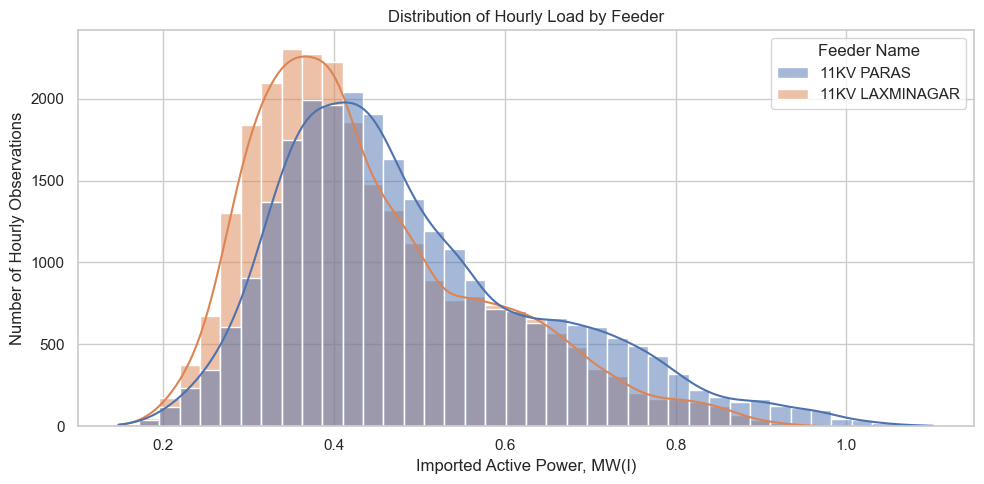

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x=target_column,
    hue="Feeder Name",
    bins=40,
    kde=True,
  
    common_norm=False
)
plt.title("Distribution of Hourly Load by Feeder")
plt.xlabel("Imported Active Power, MW(I)")
plt.ylabel("Number of Hourly Observations")
plt.tight_layout()
plt.show()

## Compare feeder load with a box plot

A box plot summarizes the median, interquartile range, and values beyond the usual 1.5 × IQR whiskers. Such points are statistical outlier candidates, not automatically incorrect readings.

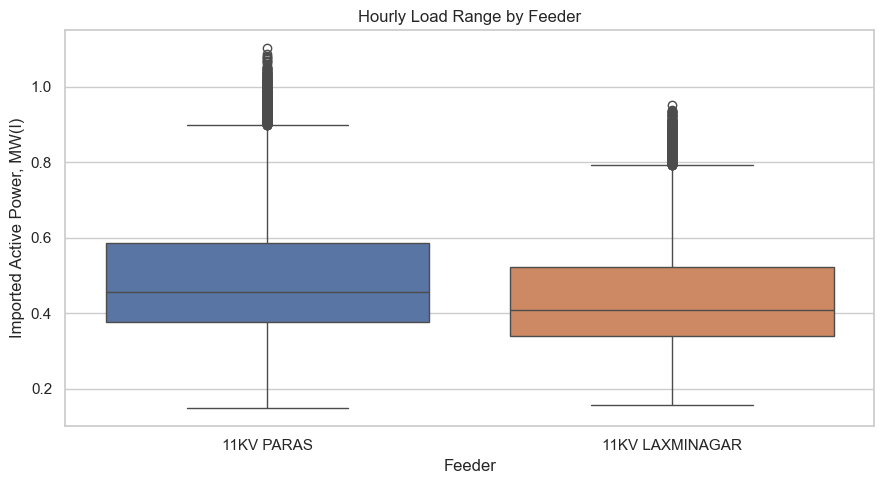

In [31]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df,
    x="Feeder Name",
    y=target_column,
    hue="Feeder Name",
    legend=False
)
plt.title("Hourly Load Range by Feeder")
plt.xlabel("Feeder")
plt.ylabel("Imported Active Power, MW(I)")
plt.tight_layout()
plt.show()

## Plot one week of hourly load

A one-week time-series view reveals the daily cycle and weekday-to-weekend changes without compressing all three years into an unreadable chart.

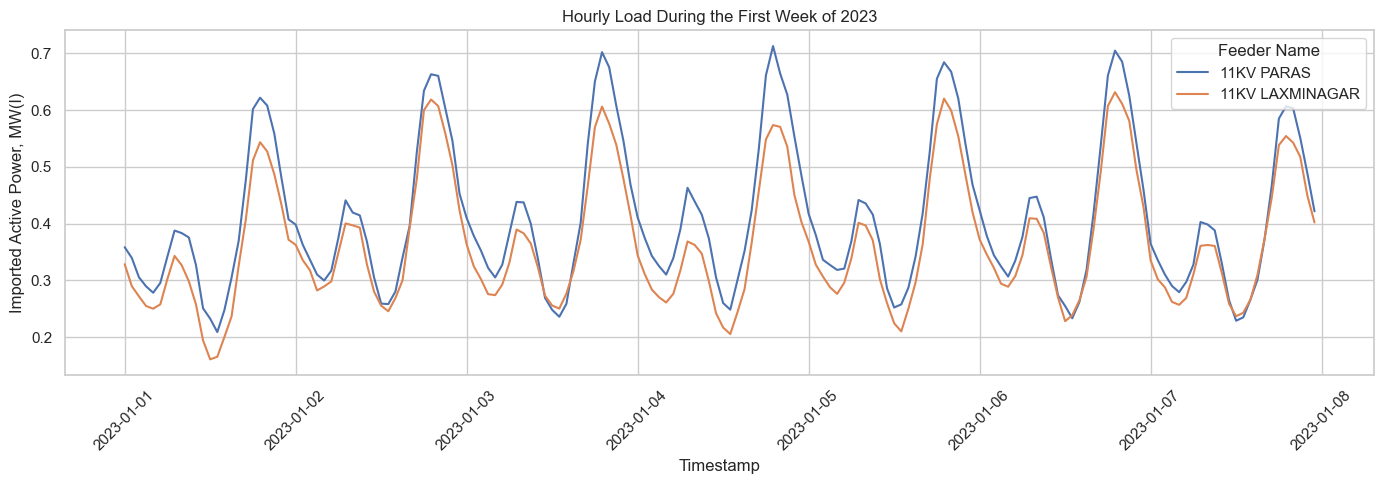

In [39]:
sample_start = df["timestamp"].min()
sample_end = sample_start + pd.Timedelta(days=7)

one_week = df[
    (df["timestamp"] >= sample_start)
    & (df["timestamp"] < sample_end)
]

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=one_week,
    x="timestamp",
    y=target_column,
    hue="Feeder Name"
)
plt.title("Hourly Load During the First Week of 2023")
plt.xlabel("Timestamp")
plt.ylabel("Imported Active Power, MW(I)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Examine the average hourly load pattern

We extract the hour of day from `timestamp`, then calculate the mean load for each feeder and hour. This reveals the typical daily demand profile.

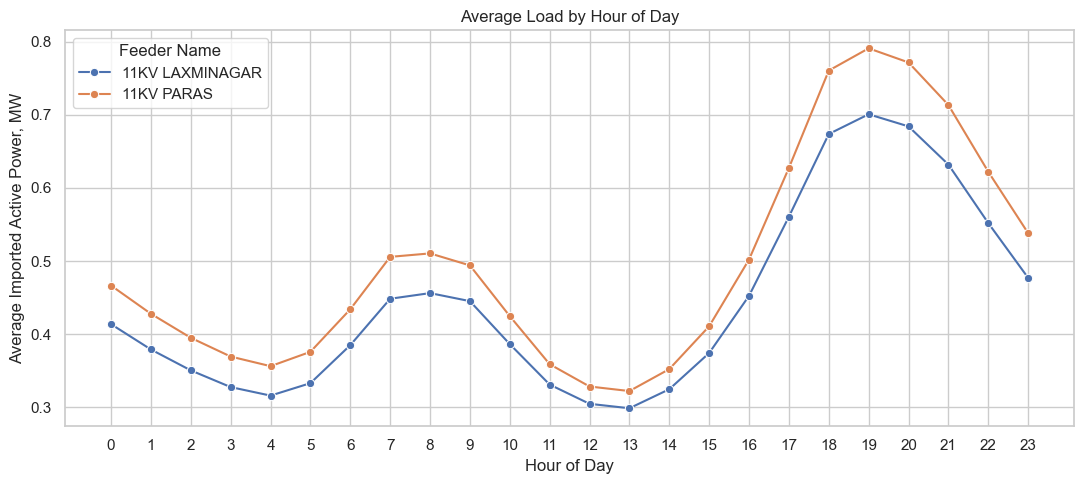

In [37]:
df["hour"] = df["timestamp"].dt.hour

average_load_by_hour = (
    df.groupby(["Feeder Name", "hour"])[target_column]
      .mean()
      .reset_index(name="average_load_mw")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=average_load_by_hour,
    x="hour",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Examine the average weekly load pattern

Average load by weekday helps identify differences between working days and weekends. This also tests whether weekday information is likely to be useful for forecasting.

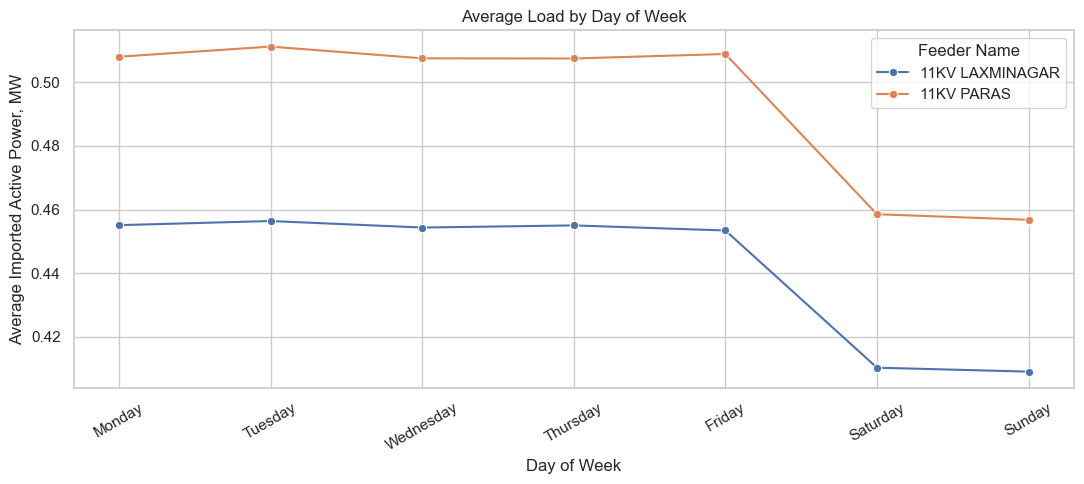

In [38]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

df["day_of_week"] = df["timestamp"].dt.day_name()
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=weekday_order,
    ordered=True
)

average_load_by_weekday = (
    df.groupby(
        ["Feeder Name", "day_of_week"],
        observed=True
    )[target_column]
    .mean()
    .reset_index(name="average_load_mw")
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=average_load_by_weekday,
    x="day_of_week",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Examine the average monthly load pattern

Monthly averages summarize seasonal changes across the three-year period. Month names are stored as an ordered category so the chart follows the calendar rather than alphabetical order.

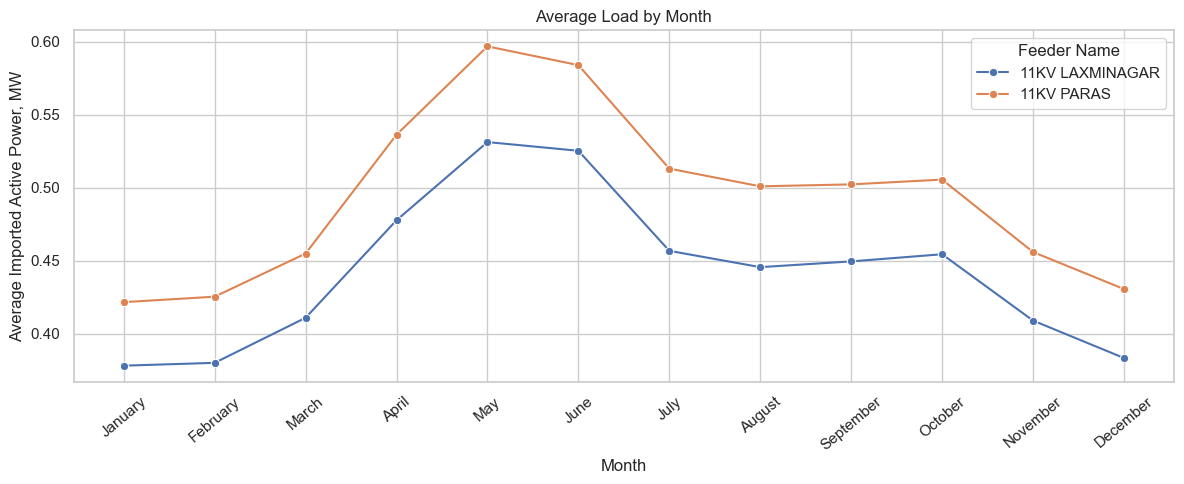

In [40]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["month_name"] = df["timestamp"].dt.month_name()
df["month_name"] = pd.Categorical(
    df["month_name"],
    categories=month_order,
    ordered=True
)

average_load_by_month = (
    df.groupby(
        ["Feeder Name", "month_name"],
        observed=True
    )[target_column]
    .mean()
    .reset_index(name="average_load_mw")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=average_load_by_month,
    x="month_name",
    y="average_load_mw",
    hue="Feeder Name",
    marker="o"
)
plt.title("Average Load by Month")
plt.xlabel("Month")
plt.ylabel("Average Imported Active Power, MW")
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

## Visualize hourly and weekly patterns together

Each heatmap cell represents the average load for one weekday-hour combination. Darker or lighter areas reveal recurring peak and low-load periods for each feeder.

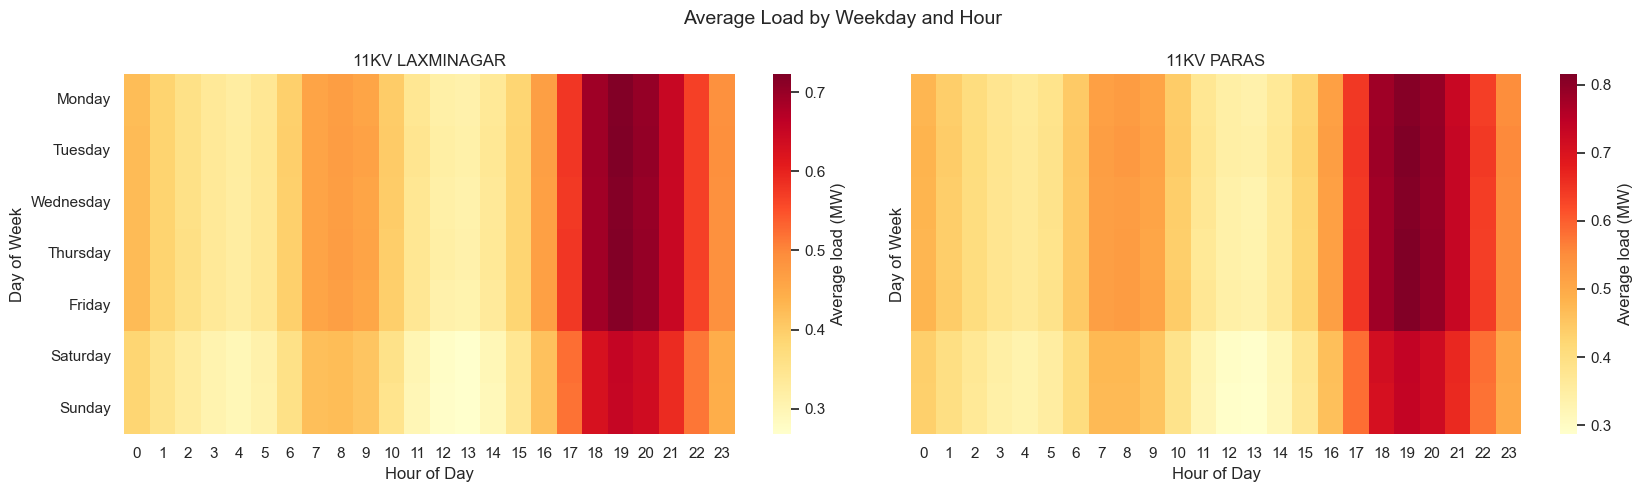

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)

for axis, feeder_name in zip(axes, sorted(df["Feeder Name"].unique())):
    feeder_data = df[df["Feeder Name"] == feeder_name]
    heatmap_data = feeder_data.pivot_table(
        index="day_of_week",
        columns="hour",
        values=target_column,
        aggfunc="mean",
        observed=True
    )

    sns.heatmap(
        heatmap_data,
        cmap="YlOrRd",
        ax=axis,
        cbar_kws={"label": "Average load (MW)"}
    )
    axis.set_title(feeder_name)
    axis.set_xlabel("Hour of Day")
    axis.set_ylabel("Day of Week")

fig.suptitle("Average Load by Weekday and Hour", fontsize=14)
plt.tight_layout()
plt.show()

## Examine correlation between numeric measurements

Pearson correlation measures the strength of a linear relationship from -1 to +1. We use a focused set of operational measurements so the heatmap remains readable. Correlation is exploratory evidence; it does not prove causation or confirm that a field is valid for day-ahead forecasting.

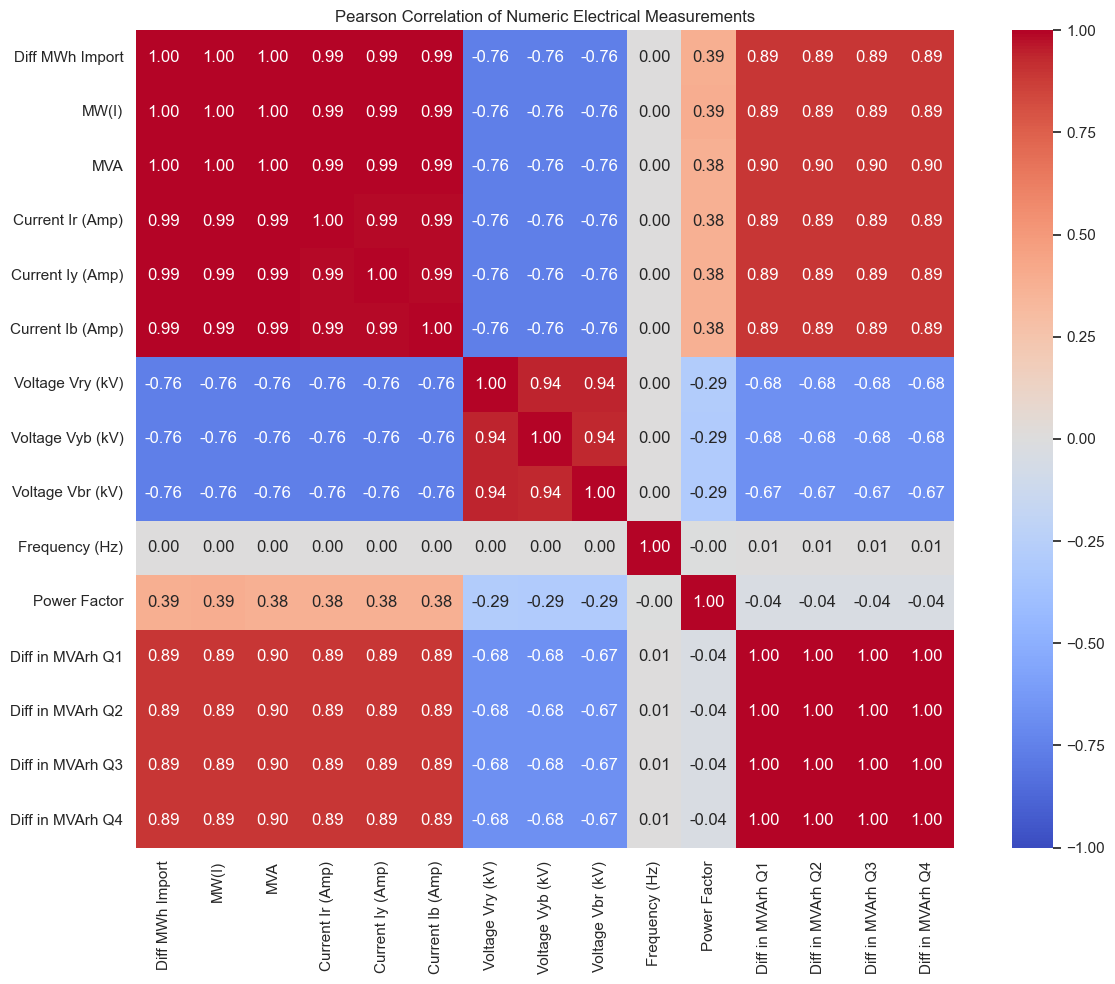

In [45]:
correlation_columns = [
    "Diff MWh Import",
    "MW(I)",
    "MVA",
    "Current Ir (Amp)",
    "Current Iy (Amp)",
    "Current Ib (Amp)",
    "Voltage Vry (kV)",
    "Voltage Vyb (kV)",
    "Voltage Vbr (kV)",
    "Frequency (Hz)",
    "Power Factor",
    "Diff in MVArh Q1",
    "Diff in MVArh Q2",
    "Diff in MVArh Q3",
    "Diff in MVArh Q4"
]

correlation_matrix = df[correlation_columns].corr(method="pearson")

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True
)
plt.title("Pearson Correlation of Numeric Electrical Measurements")
plt.tight_layout()
plt.show()

## Rank numeric relationships with the target

We extract the `MW(I)` column from the correlation matrix and rank measurements by absolute correlation. These values describe same-hour relationships only; they are not automatically selected as day-ahead predictors.

In [ ]:
target_correlations = (
    correlation_matrix[target_column]
      .drop(labels=target_column)
      .rename("pearson_correlation_with_target")
      .to_frame()
)

target_correlations["absolute_correlation"] = (
    target_correlations["pearson_correlation_with_target"].abs()
)

target_correlations = (
    target_correlations
      .sort_values("absolute_correlation", ascending=False)
      .round(3)
)

target_correlations

**Forecasting decision:** Same-hour electrical measurements are excluded from model inputs because their future values are unavailable when a day-ahead forecast is issued. Historical `MW(I)` lags and known calendar information will form the main feature set.

# Add external weather and holiday information

We add hourly temperature and relative humidity for Rajkot, plus Gujarat public holidays for 2023–2025. Weather comes from Open-Meteo's Historical Forecast API. It is a continuous historical forecast series rather than a controlled archive of forecasts issued at exactly the same 24-hour lead time, so this limitation must be stated when interpreting model performance.

In [92]:
weather_file = project_root / "external_data" / "rajkot_hourly_weather_2023_2025.csv"
holiday_file = project_root / "external_data" / "gujarat_public_holidays_2023_2025.csv"

weather = pd.read_csv(weather_file, parse_dates=["timestamp"])
holidays = pd.read_csv(holiday_file, parse_dates=["date"])

print(f"Weather rows: {len(weather):,}")
print(f"Holiday dates: {len(holidays):,}")
display(weather.head())
display(holidays.head())

Weather rows: 26,304
Holiday dates: 75


,timestamp,temperature_c,humidity_percent
0,2023-01-01 00:00:00,15.8,43
1,2023-01-01 01:00:00,14.8,47
2,2023-01-01 02:00:00,13.9,50
3,2023-01-01 03:00:00,13.2,53
4,2023-01-01 04:00:00,13.0,53


,date,holiday_name
0,2023-01-14,Uttarayan
1,2023-01-26,Republic Day
2,2023-03-08,Holi
3,2023-03-22,Cheti Chand
4,2023-03-30,Ram Navami


## Validate the external datasets

Before merging, we check time coverage, duplicates, missing values, and reasonable measurement ranges. This prevents an incorrect external-data join from silently damaging the modelling table.

In [ ]:
print("Weather period:", weather["timestamp"].min(), "to", weather["timestamp"].max())
print("Duplicate weather timestamps:", weather["timestamp"].duplicated().sum())
print("Missing weather values:")
display(weather.isna().sum().to_frame("missing_count"))

invalid_temperature_count = (~weather["temperature_c"].between(-10, 55)).sum()
invalid_humidity_count = (~weather["humidity_percent"].between(0, 100)).sum()
duplicate_holiday_dates = holidays["date"].duplicated().sum()

print("Temperatures outside -10 to 55 °C:", invalid_temperature_count)
print("Humidity values outside 0 to 100%:", invalid_humidity_count)
print("Duplicate holiday dates:", duplicate_holiday_dates)

## Merge weather and holiday data

Weather is joined by hourly timestamp. Because both feeders share Rajkot weather, many feeder rows match one weather row. Holidays are joined by calendar date and converted to a binary `is_holiday` feature.

In [ ]:
external_columns = [
    "temperature_c", "humidity_percent", "calendar_date",
    "date", "holiday_name", "is_holiday"
]
df = df.drop(columns=external_columns, errors="ignore")

rows_before_merge = len(df)

df = df.merge(
    weather,
    on="timestamp",
    how="left",
    validate="many_to_one"
)

df["calendar_date"] = df["timestamp"].dt.normalize()
holidays["is_holiday"] = 1

df = df.merge(
    holidays,
    left_on="calendar_date",
    right_on="date",
    how="left",
    validate="many_to_one"
)

df["is_holiday"] = df["is_holiday"].fillna(0).astype(int)
df["holiday_name"] = df["holiday_name"].fillna("No holiday")
df = df.drop(columns="date")

print("Rows before merge:", f"{rows_before_merge:,}")
print("Rows after merge: ", f"{len(df):,}")

## Verify the merged features

The row count must remain unchanged, and temperature, humidity, and holiday indicators must be complete after the joins.

In [ ]:
external_feature_columns = [
    "temperature_c",
    "humidity_percent",
    "is_holiday"
]

print("Missing merged feature values:")
display(df[external_feature_columns].isna().sum().to_frame("missing_count"))

print("Holiday and non-holiday hourly feeder rows:")
display(df["is_holiday"].value_counts().sort_index().rename_axis("is_holiday").to_frame("row_count"))

df[[
    "timestamp", "Feeder Name", target_column,
    "temperature_c", "humidity_percent",
    "is_holiday", "holiday_name"
]].head()

## Keep 2026 future inputs separate

The files `rajkot_synthetic_weather_2026.csv` and `gujarat_public_holidays_2026.csv` are intentionally not merged into `df`. The modelling dataset ends in 2025. These 2026 inputs will be loaded only after the final model is trained, when we build the future day-ahead forecast demonstration. This separation prevents future-input information from entering training or test evaluation.

## Examine external-feature relationships with load

We examine the linear relationships of temperature and humidity with `MW(I)`, then compare average load on holidays and ordinary days. These summaries support feature evaluation but do not replace temporal model validation.

In [90]:
external_numeric_correlation = (
    df[[target_column, "temperature_c", "humidity_percent"]]
      .corr(method="pearson")[target_column]
      .drop(labels=target_column)
      .rename("correlation_with_load")
      .to_frame()
      .round(3)
)

holiday_load_summary = (
    df.groupby(["Feeder Name", "is_holiday"])[target_column]
      .agg(observation_count="count", average_load_mw="mean")
      .reset_index()
)
holiday_load_summary["day_type"] = holiday_load_summary["is_holiday"].map({
    0: "Non-holiday",
    1: "Holiday"
})

print("Weather correlation with MW(I):")
display(external_numeric_correlation)

print("Average load by holiday status:")
display(holiday_load_summary[[
    "Feeder Name", "day_type",
    "observation_count", "average_load_mw"
]].round(3))

Weather correlation with MW(I):


,correlation_with_load
temperature_c,0.171
humidity_percent,0.035


Average load by holiday status:


,Feeder Name,day_type,observation_count,average_load_mw
0,11KV LAXMINAGAR,Non-holiday,24504,0.442
1,11KV LAXMINAGAR,Holiday,1800,0.448
2,11KV PARAS,Non-holiday,24504,0.494
3,11KV PARAS,Holiday,1800,0.500


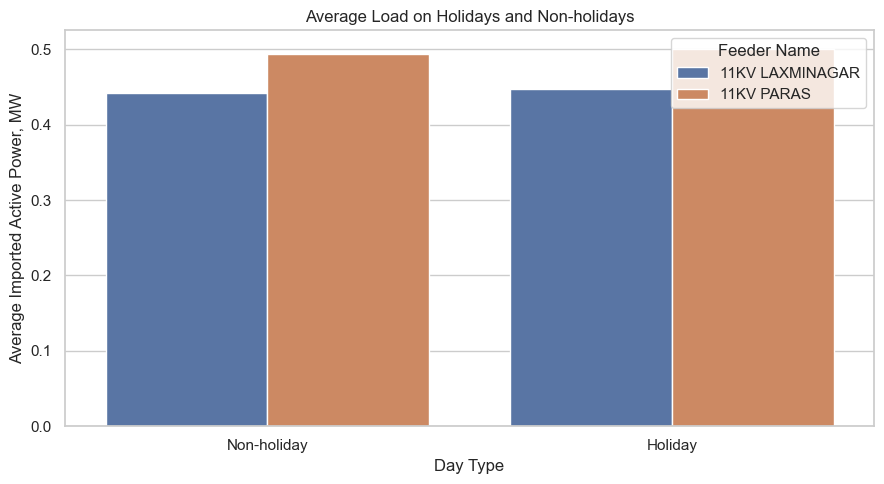

In [91]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=holiday_load_summary,
    x="day_type",
    y="average_load_mw",
    hue="Feeder Name"
)
plt.title("Average Load on Holidays and Non-holidays")
plt.xlabel("Day Type")
plt.ylabel("Average Imported Active Power, MW")
plt.tight_layout()
plt.show()

# Model feature engineering

We now construct the leakage-safe variables intended for model training. Calendar features are known in advance for every future forecast timestamp.

## Create numeric calendar features

Month and weekday names were useful for charts, but models require consistent numeric inputs. Monday is represented by 0 and Sunday by 6. The weekend indicator equals 1 for Saturday and Sunday.

In [94]:
df["month"] = df["timestamp"].dt.month
df["day_of_week_number"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week_number"] >= 5).astype(int)

calendar_feature_columns = [
    "timestamp",
    "hour",
    "day_of_week_number",
    "month",
    "is_weekend",
    "is_holiday"
]

df[calendar_feature_columns].head()

,timestamp,hour,day_of_week_number,month,is_weekend,is_holiday
0,2023-01-01 00:00:00,0,6,1,1,0
1,2023-01-01 01:00:00,1,6,1,1,0
2,2023-01-01 02:00:00,2,6,1,1,0
3,2023-01-01 03:00:00,3,6,1,1,0
4,2023-01-01 04:00:00,4,6,1,1,0


In [95]:
print("Month values:", sorted(df["month"].unique()))
print("Day-of-week values:", sorted(df["day_of_week_number"].unique()))
print("Weekend values:", sorted(df["is_weekend"].unique()))

Month values: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Day-of-week values: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Weekend values: [np.int64(0), np.int64(1)]


## Create cyclical calendar features

Calendar variables repeat in cycles. Sine and cosine encoding places the beginning and end of each cycle close together—for example, hour 23 is close to hour 0, and December is close to January.

In [96]:
import numpy as np

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_of_week_sin"] = np.sin(
    2 * np.pi * df["day_of_week_number"] / 7
)
df["day_of_week_cos"] = np.cos(
    2 * np.pi * df["day_of_week_number"] / 7
)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)

cyclical_feature_columns = [
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos"
]

df[["timestamp"] + cyclical_feature_columns].head()

,timestamp,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2023-01-01 00:00:00,0.000000,1.000000,-0.781831,0.62349,0.0,1.0
1,2023-01-01 01:00:00,0.258819,0.965926,-0.781831,0.62349,0.0,1.0
2,2023-01-01 02:00:00,0.500000,0.866025,-0.781831,0.62349,0.0,1.0
3,2023-01-01 03:00:00,0.707107,0.707107,-0.781831,0.62349,0.0,1.0
4,2023-01-01 04:00:00,0.866025,0.500000,-0.781831,0.62349,0.0,1.0


## Create historical load-lag features

Lag features provide earlier values of the prediction target. They must be calculated separately for each feeder and only after sorting records chronologically. For a day-ahead forecast, lags of 24 hours or longer are available when the forecast is issued.

In [97]:
df = (
    df.sort_values(["Code no of Feeder", "timestamp"])
      .reset_index(drop=True)
)

load_by_feeder = df.groupby("Code no of Feeder")[target_column]

df["load_lag_24"] = load_by_feeder.shift(24)
df["load_lag_48"] = load_by_feeder.shift(48)
df["load_lag_168"] = load_by_feeder.shift(168)

lag_feature_columns = ["load_lag_24", "load_lag_48", "load_lag_168"]

df[[
    "timestamp", "Feeder Name", target_column
] + lag_feature_columns].head(170)

,timestamp,Feeder Name,MW(I),load_lag_24,load_lag_48,load_lag_168
0,2023-01-01 00:00:00,11KV PARAS,0.358373,NaN,NaN,NaN
1,2023-01-01 01:00:00,11KV PARAS,0.339442,NaN,NaN,NaN
2,2023-01-01 02:00:00,11KV PARAS,0.305423,NaN,NaN,NaN
3,2023-01-01 03:00:00,11KV PARAS,0.289466,NaN,NaN,NaN
4,2023-01-01 04:00:00,11KV PARAS,0.278155,NaN,NaN,NaN
...,...,...,...,...,...,...
165,2023-01-07 21:00:00,11KV PARAS,0.550870,0.625266,0.620199,NaN
166,2023-01-07 22:00:00,11KV PARAS,0.488373,0.542450,0.541107,NaN
167,2023-01-07 23:00:00,11KV PARAS,0.421581,0.459129,0.468461,NaN
168,2023-01-08 00:00:00,11KV PARAS,0.351049,0.364298,0.423711,0.358373


In [98]:
lag_missing_summary = (
    df.groupby("Feeder Name")[lag_feature_columns]
      .agg(lambda values: values.isna().sum())
)

lag_missing_summary

,load_lag_24,load_lag_48,load_lag_168
Feeder Name,,,
11KV LAXMINAGAR,24,48,168
11KV PARAS,24,48,168
